In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

In [41]:
df=pd.read_csv(r'Fifa.csv')
df

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.650,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.350,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.200,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.500,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.400,1640
...,...,...,...,...,...,...,...,...,...
19662,Kohei Okuno,Japan,CDM,21,63,71,Gamba Osaka,1.100,1717
19663,Riku Danzaki,Japan,RW,22,64,71,Motherwell,1.200,1607
19664,Hayato Fukushima,Japan,CB,21,59,68,Shonan Bellmare,0.475,1347
19665,Ömer Tokaç,Turkey,LW,18,57,71,Shonan Bellmare,0.220,1481


---
## Task 1 — Exploratory Data Analysis (EDA)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [43]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

### there are no missing values

In [44]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


Skewness: 7.983
Mean: 2.51
Median: 0.68


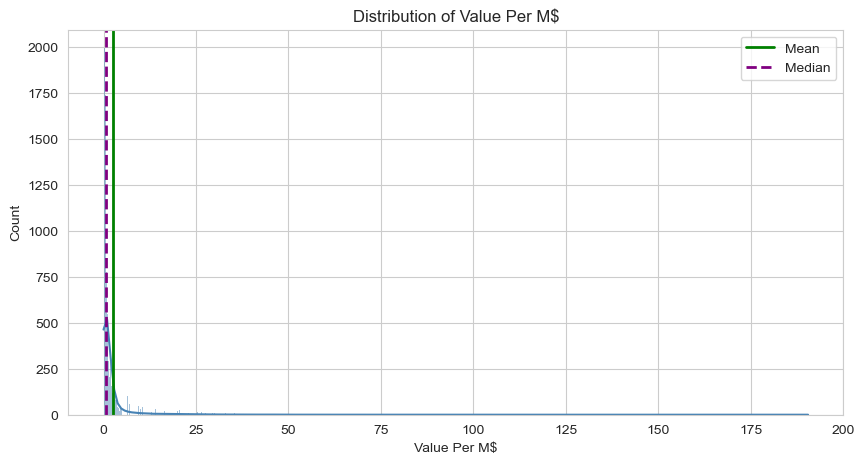

In [45]:
reg_target = 'Value Per M$'

#compute skewness
skewness = df['Value Per M$'].skew()  
print(f"Skewness: {skewness:.3f}")
print(f"Mean: {df['Value Per M$'].mean():.2f}")
print(f"Median: {df['Value Per M$'].median():.2f}")


plt.figure(figsize=(10, 5))
sns.histplot(df['Value Per M$'], kde=True, color='steelblue')
plt.axvline(df['Value Per M$'].mean(), color='green', label='Mean', lw=2)
plt.axvline(df['Value Per M$'].median(), color='purple', ls='--', label='Median', lw=2)
plt.xlabel('Value Per M$')
plt.legend()
plt.title('Distribution of Value Per M$')
plt.show()

 The Distribution is right skewed (mean>median)

###  Correlation with `Value Per M$`

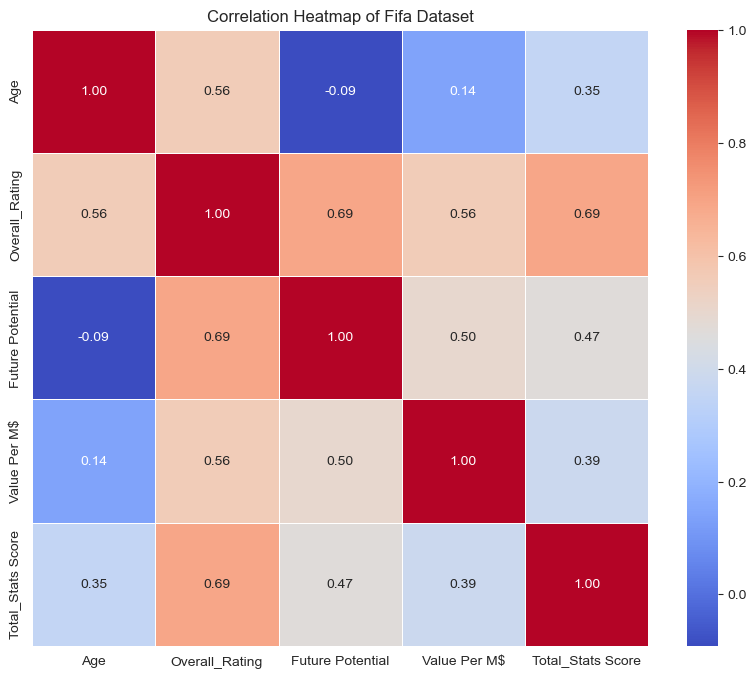

In [46]:

num_col=df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df[num_col].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, 
           linewidths=0.5)

# Add title and labels
plt.title('Correlation Heatmap of Fifa Dataset')
plt.show()

In [47]:
#most related to Value Per M$
target_corr = correlation_matrix['Value Per M$'].drop('Value Per M$')  

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("Most correlated features with 'Value Per M$':\n")
print(target_corr_sorted.head(10))

Most correlated features with 'Value Per M$':

Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


###  Average `Overall_Rating` per Position

In [48]:
avg_rating = (
    df.groupby('Position')['Overall_Rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print(avg_rating.to_string(index=False))

Position  Overall_Rating
      SW       75.000000
      RF       75.000000
      CF       66.042857
      LW       64.345979
     CDM       64.234168
      LM       64.172009
     RWB       64.063973
     LWB       64.043333
      RM       63.907731
      RW       63.718529
     CAM       63.679709
      CB       63.544448
      LB       63.276794
      ST       63.087505
      RB       62.863636
      CM       62.511767
      GK       60.987288


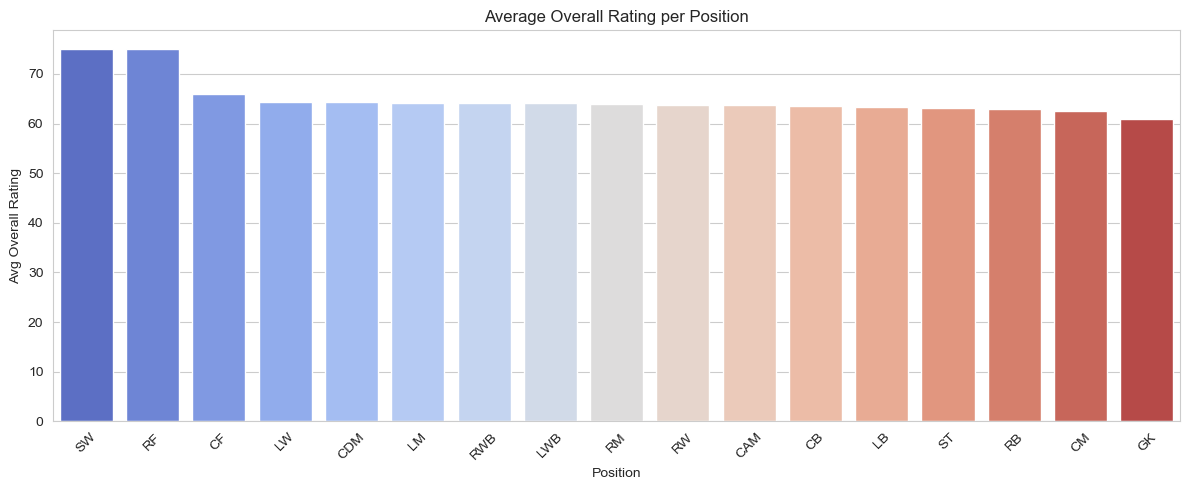

In [49]:
plt.figure(figsize=(12, 5))
sns.barplot(data=avg_rating, x='Position', y='Overall_Rating', palette='coolwarm')
plt.title('Average Overall Rating per Position')
plt.ylabel('Avg Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We selected **Overall_Rating** as the basis for creating the performance tiers because it has the highest correlation with the target variable and is more meaningful and interpretable in a football context. 

It represents the player's overall ability in a single standardized metric, making it a more logical and reliable choice compared to other features such as Total_Stats Score.

In [50]:
df['Tier'] = pd.qcut(df['Overall_Rating'] , q=4 , labels=['Low','Mid','High','Elite'])

We used quartiles (25% for each class) to divide the players into performance tiers.  
This approach is data-driven and ensures a balanced distribution across all classes.


In [51]:
df['Tier'].value_counts()

Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64

In [52]:
class_target='Tier'

Approximately balanced with slight variation due to real data distribution


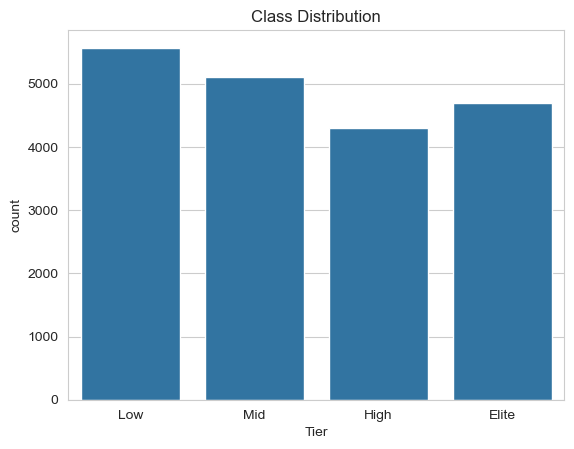

In [53]:
sns.set_style("whitegrid")
sns.countplot(x='Tier', data=df)
plt.title("Class Distribution")
plt.show()

## Data Preprocessing

In [54]:
#identifier — not a feature
df.drop(columns=[('Name')],inplace=True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Country            19667 non-null  object  
 1   Position           19667 non-null  object  
 2   Age                19667 non-null  int64   
 3   Overall_Rating     19667 non-null  int64   
 4   Future Potential   19667 non-null  int64   
 5   Team               19667 non-null  object  
 6   Value Per M$       19667 non-null  float64 
 7   Total_Stats Score  19667 non-null  int64   
 8   Tier               19667 non-null  category
dtypes: category(1), float64(1), int64(4), object(3)
memory usage: 1.2+ MB


In [56]:
cat_col = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical features:",num_col)
print("Categorical features:",cat_col)

Numerical features: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
Categorical features: ['Country', 'Position', 'Team', 'Tier']


In [57]:
for col in cat_col:
    print(f"{col}: {df[col].nunique()} unique values")

Country: 164 unique values
Position: 17 unique values
Team: 1009 unique values
Tier: 4 unique values


In [58]:
for col in cat_col:
    print(f"{col}: {df[col].unique()} unique values")


Country: ['Angola' 'Egypt' 'Nigeria' 'Senegal' 'Uruguay' 'Ukraine' 'Mexico'
 'England' 'Paraguay' 'France' 'Belgium' 'Spain' 'Georgia' 'Hungary'
 'Argentina' 'Republic of Ireland' 'Italy' 'Ecuador' 'Germany' 'Brazil'
 'Netherlands' 'Denmark' 'Turkey' 'Portugal' 'Norway' 'Japan' 'Croatia'
 'Korea Republic' 'Serbia' 'Czech Republic' 'Albania' 'Wales'
 "Côte d'Ivoire" 'Slovenia' 'Sweden' 'Canada' 'United States' 'Ghana'
 'Poland' 'Morocco' 'Austria' 'Slovakia' 'Kosovo' 'Libya' 'Algeria'
 'Switzerland' 'Qatar' 'Scotland' 'Israel' 'Burkina Faso' 'Gabon'
 'Cameroon' 'Chile' 'Colombia' 'Peru' 'Australia' 'Jamaica' 'Greece'
 'Puerto Rico' 'Luxembourg' 'Guinea' 'Venezuela' 'Costa Rica' 'Romania'
 'Mali' 'Suriname' 'Trinidad and Tobago' 'Bosnia and Herzegovina'
 'North Macedonia' 'Iran' 'Gambia' 'Northern Ireland' 'Iceland' 'Armenia'
 'New Zealand' 'China PR' 'Central African Republic' 'Iraq' 'Bulgaria'
 'Liberia' 'Finland' 'Congo DR' 'Burundi' 'Zambia' 'Saudi Arabia'
 'Tunisia' 'Russia' 'Togo' 

In [59]:
print(df['Team'].unique())

['Ittihad Alexandria' 'Tottenham Hotspur' 'Sporting CP' ...
 'Neuchâtel Xamax' 'Mattersburg' 'Deportivo La Coruña']


In [60]:
le = LabelEncoder()
df['Tier'] = le.fit_transform(df['Tier'])

X = df.drop(columns=['Value Per M$', 'Tier'])
y_reg = df['Value Per M$']
y_clf = df['Tier']

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train size: 15733  |  Test size: 3934


In [61]:
X_train

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Japan,LW,25,67,70,Gil Vicente,1689
10392,Colombia,ST,19,55,68,Midtjylland,1351
8124,Portugal,RW,32,75,75,Rio Ave,2049
13075,Portugal,ST,17,61,71,Belenenses,1448
19445,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...
11284,Ecuador,CM,19,59,70,Delfin,1680
11964,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Nigeria,CM,25,81,82,Leicester City,2042


In [62]:
X_test

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
15659,Uruguay,CDM,34,68,68,Torque,1708
1350,Spain,CB,31,82,82,Athletic Club,1992
4871,Belgium,CM,22,59,65,RKC Waalwijk,1540
16532,Brazil,CDM,23,68,73,Vancouver Whitecaps,1830
385,Serbia,CM,27,86,86,Lazio,2250
...,...,...,...,...,...,...,...
7628,Ukraine,CB,32,78,78,Shakhtar Donetsk,2071
17406,Belgium,LW,20,56,70,Mechelen,1470
5963,Argentina,RW,26,74,75,Charlotte,1970
14024,Denmark,RW,19,62,75,Viborg,1606


In [63]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(X_train[['Position']])  # only train

pos_cols = ohe.get_feature_names_out(['Position'])

pos_train = pd.DataFrame(ohe.transform(X_train[['Position']]), columns=pos_cols, index=X_train.index)
pos_test  = pd.DataFrame(ohe.transform(X_test[['Position']]),  columns=pos_cols, index=X_test.index)

X_train = pd.concat([X_train, pos_train], axis=1).drop(columns=['Position'])
X_test  = pd.concat([X_test,  pos_test],  axis=1).drop(columns=['Position'])

In [64]:
X_train_reg = X_train.copy()
X_test_reg  = X_test.copy()

X_train_clf = X_train.copy()
X_test_clf  = X_test.copy()

In [65]:
X_train_clf.drop(columns=['Overall_Rating'], inplace=True)
X_test_clf.drop(columns=['Overall_Rating'], inplace=True)

In [66]:
def target_encode_train(X_train_reg, y_reg_train, col, n_splits=5, random_state=42):
    global_mean = y_reg_train.mean()
    encoded = pd.Series(global_mean, index=X_train_reg.index)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(X_train_reg):
        fold_means = y_reg_train.iloc[train_idx].groupby(X_train_reg[col].iloc[train_idx]).mean()
        encoded.iloc[val_idx] = X_train_reg[col].iloc[val_idx].map(fold_means).fillna(global_mean)

    
    full_means = y_reg_train.groupby(X_train_reg[col]).mean()
    return encoded, full_means, global_mean


for col in ['Country', 'Team']:
    enc_train, means, global_mean = target_encode_train(X_train_reg, y_reg_train, col)
    
    X_train_reg[f'{col}_enc'] = enc_train
    X_test_reg[f'{col}_enc']  = X_test_reg[col].map(means).fillna(global_mean)  
    
    X_train_reg = X_train_reg.drop(columns=[col])
    X_test_reg  = X_test_reg.drop(columns=[col])

print("Train shape:", X_train_reg.shape)
print("Test shape:",  X_test_reg.shape)

Train shape: (15733, 22)
Test shape: (3934, 22)


In [67]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,25,67,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.497152,2.802500
10392,19,55,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.080662,1.798333
8124,32,75,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.901309,1.300000
13075,17,61,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.755643,1.718750
19445,28,69,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.538141,1.055000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.232550,0.528889
11964,27,67,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.328409,0.716667
5390,24,63,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.390830,0.437500
860,25,81,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.391250,10.655714


In [68]:
def target_encode_train_cly(X_train_clf, y_clf_train, col, n_splits=5, random_state=42):
    global_mean = y_clf_train.mean()
    encoded = pd.Series(global_mean, index=X_train_clf.index)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(X_train_clf):
        fold_means = y_clf_train.iloc[train_idx].groupby(X_train_clf[col].iloc[train_idx]).mean()
        encoded.iloc[val_idx] = X_train_clf[col].iloc[val_idx].map(fold_means).fillna(global_mean)

    
    full_means = y_clf_train.groupby(X_train_clf[col]).mean()
    return encoded, full_means, global_mean


for col in ['Country', 'Team']:
    enc_train, means, global_mean = target_encode_train_cly(X_train_clf, y_clf_train, col)
    
    X_train_clf[f'{col}_enc'] = enc_train
    X_test_clf[f'{col}_enc']  = X_test_clf[col].map(means).fillna(global_mean)  
    
    X_train_clf = X_train_clf.drop(columns=[col])
    X_test_clf  = X_test_clf.drop(columns=[col])

print("Train shape(classifaction):", X_train_clf.shape)
print("Test shape(classifaction):",  X_test_clf.shape)

Train shape(classifaction): (15733, 21)
Test shape(classifaction): (3934, 21)


In [83]:
#scaling

cols_to_scale = ['Age', 'Future Potential', 'Total_Stats Score', 
                 'Country_enc', 'Team_enc','Overall_Rating']
scaler = StandardScaler()

X_train_reg[cols_to_scale] = scaler.fit_transform(X_train_reg[cols_to_scale])
X_test_reg[cols_to_scale]  = scaler.transform(X_test_reg[cols_to_scale])

print(X_train_reg[cols_to_scale].describe().round(2))

            Age  Future Potential  Total_Stats Score  Country_enc  Team_enc  \
count  15733.00          15733.00           15733.00     15733.00  15733.00   
mean      -0.00              0.00               0.00         0.00      0.00   
std        1.00              1.00               1.00         1.00      1.00   
min       -1.72             -2.81              -2.30        -1.61     -1.15   
25%       -0.86             -0.72              -0.52        -0.84     -0.73   
50%       -0.21             -0.10               0.05        -0.12     -0.41   
75%        0.65              0.67               0.66         0.76      0.35   
max        2.91              2.76               2.44         3.14      1.97   

       Overall_Rating  
count        15733.00  
mean            -0.00  
std              1.00  
min             -2.62  
25%             -0.68  
50%             -0.03  
75%              0.62  
max              2.56  


In [84]:
cols_to_scale = ['Age', 'Future Potential', 'Total_Stats Score', 
                 'Country_enc', 'Team_enc']
X_train_clf[cols_to_scale] = scaler.fit_transform(X_train_clf[cols_to_scale])
X_test_clf[cols_to_scale]  = scaler.transform(X_test_clf[cols_to_scale])

In [85]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,0.435531,0.489099,-0.102944,0.550469,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.644150,0.955672
10392,-0.858009,-1.063694,-0.412772,-0.660739,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.266423,0.200541
8124,1.944660,1.524295,0.671625,1.840512,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.206820,-0.174204
13075,-1.289189,-0.287298,0.051969,-0.313144,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.112526,0.140695
19445,1.082300,0.747898,-0.257858,0.761893,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.029719,-0.358444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.858009,-0.546096,-0.102944,0.518218,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.815437,-0.754078
11964,0.866710,0.489099,-0.412772,0.077453,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.541289,-0.612870
5390,0.219941,-0.028499,-0.567686,0.116871,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.712977,-0.822802
860,0.435531,2.300692,1.756022,1.815428,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.581968,1.972874


In [86]:
X_train_clf

,Age,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,Position_LM,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,0.435531,-0.102944,0.550469,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.810736,-0.278140
10392,-0.858009,-0.412772,-0.660739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.389487,-0.390123
8124,1.944660,0.671625,1.840512,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.695497,0.169793
13075,-1.289189,0.051969,-0.313144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.579441,0.029814
19445,1.082300,-0.257858,0.761893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.512405,-0.390123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.858009,-0.102944,0.518218,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.467842,0.480858
11964,0.866710,-0.412772,0.077453,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.959563,0.869689
5390,0.219941,-0.567686,0.116871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.823240,1.196307
860,0.435531,1.756022,1.815428,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.015251,-1.509956


Outlier Report (Train only):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                          -3.12     2.91      129   0.8%
Future Potential             -2.81     2.76        0   0.0%
Total_Stats Score            -2.30     2.44       23   0.1%
Country_enc                  -3.23     3.14        9   0.1%
Team_enc                     -2.35     1.97        0   0.0%
Overall_Rating               -2.62     2.56      162   1.0%


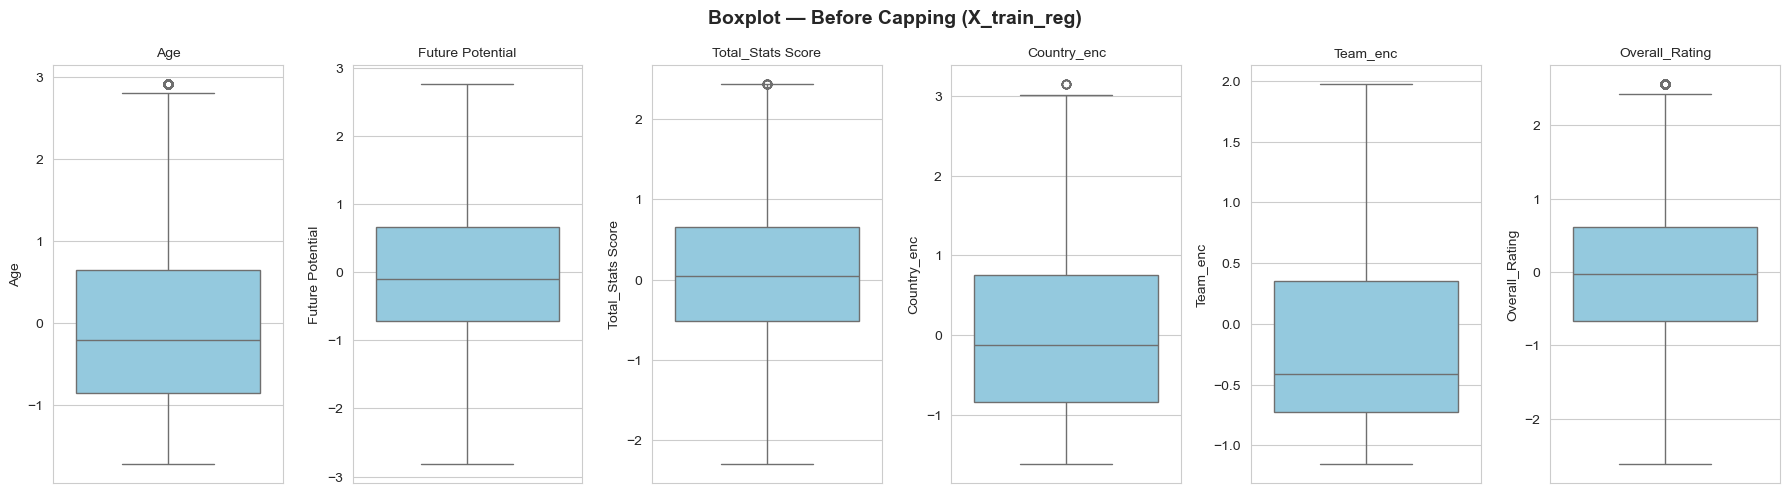

In [87]:

num_cols = ['Age', 'Future Potential', 'Total_Stats Score', 
            'Country_enc', 'Team_enc','Overall_Rating']

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return lower, upper, len(outliers)


print("Outlier Report (Train only):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols:
    lower, upper, count = detect_outliers_iqr(X_train_reg, col)
    pct = count / len(X_train_reg) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 6, figsize=(18, 5))
fig.suptitle('Boxplot — Before Capping (X_train_reg)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    sns.boxplot(y=X_train_reg[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


Outlier Report (Train only:Classification):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                          -3.12     2.91      129   0.8%
Future Potential             -2.81     2.76        0   0.0%
Total_Stats Score            -2.30     2.44       23   0.1%
Country_enc                  -2.56     2.74        0   0.0%
Team_enc                     -2.87     2.89        0   0.0%


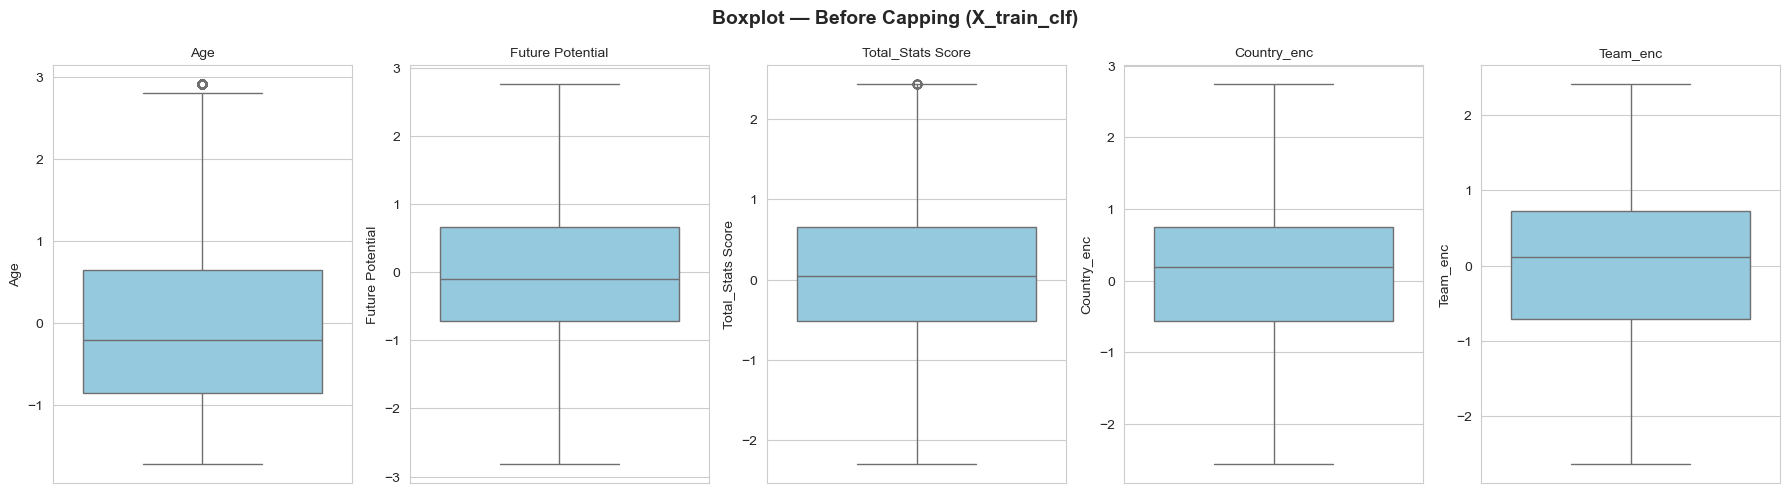

In [88]:
num_cols_clf = ['Age', 'Future Potential', 'Total_Stats Score', 
            'Country_enc', 'Team_enc']

print("Outlier Report (Train only:Classification):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols_clf:
    lower, upper, count = detect_outliers_iqr(X_train_clf, col)
    pct = count / len(X_train_clf) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplot — Before Capping (X_train_clf)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_clf):
    sns.boxplot(y=X_train_clf[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()



After Capping:
            Age  Future Potential  Total_Stats Score  Country_enc  Team_enc  \
count  15733.00          15733.00           15733.00     15733.00  15733.00   
mean      -0.00              0.00               0.01        -0.00     -0.22   
std        0.99              1.00               0.98         0.97      0.30   
min       -1.71             -2.80              -2.26        -1.57     -0.56   
25%       -0.85             -0.72              -0.51        -0.81     -0.44   
50%       -0.21             -0.10               0.05        -0.12     -0.34   
75%        0.64              0.67               0.66         0.73     -0.11   
max        2.88              2.75               2.41         3.04      0.37   

       Overall_Rating  
count        15733.00  
mean            63.22  
std              7.73  
min             43.00  
25%             58.00  
50%             63.00  
75%             68.00  
max             83.00  


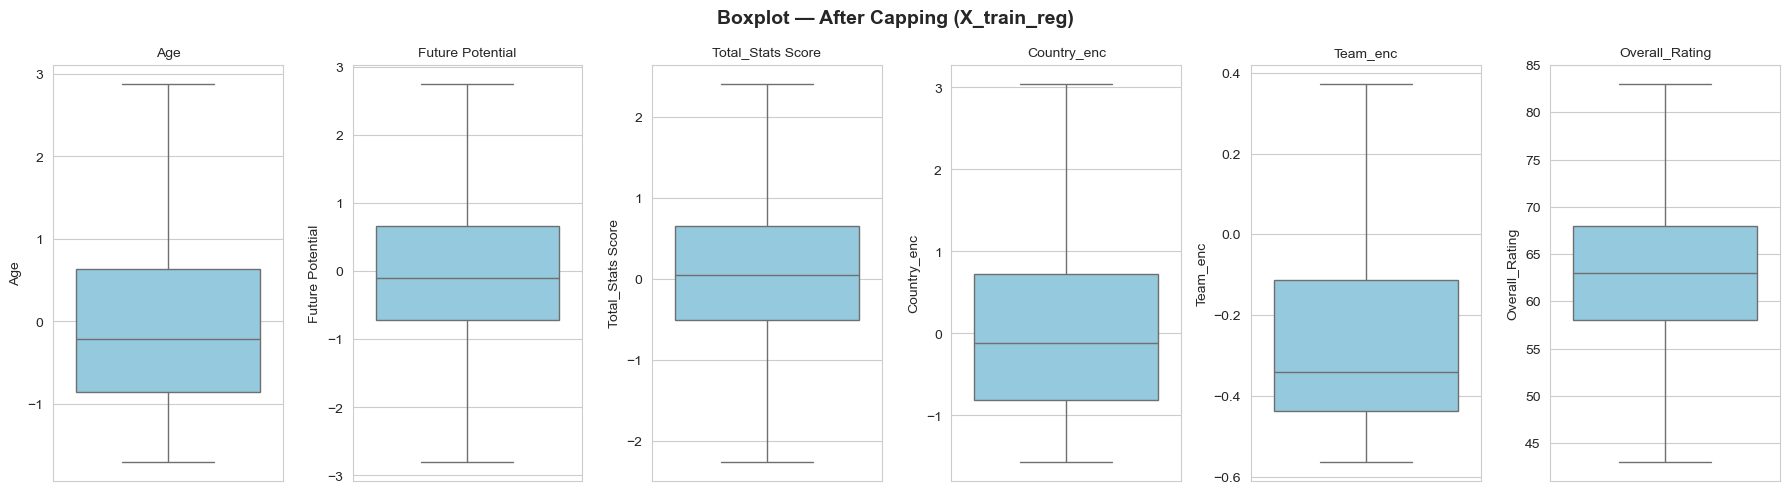

In [80]:
caps = {}

for col in num_cols:
    Q1 = X_train_reg[col].quantile(0.25)
    Q3 = X_train_reg[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    caps[col] = (lower, upper)

    X_train_reg[col] = X_train_reg[col].clip(lower, upper)

for col in num_cols:
    lower, upper = caps[col]
    X_test_reg[col] = X_test_reg[col].clip(lower, upper)

print("\nAfter Capping:")
print(X_train_reg[num_cols].describe().round(2))

fig, axes = plt.subplots(1, 6, figsize=(18, 5))
fig.suptitle('Boxplot — After Capping (X_train_reg)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    sns.boxplot(y=X_train_reg[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


After Capping:
            Age  Future Potential  Total_Stats Score  Country_enc  Team_enc
count  15733.00          15733.00           15733.00     15733.00  15733.00
mean      -0.00              0.00               0.01         0.00      0.00
std        0.99              1.00               0.98         0.98      1.00
min       -1.71             -2.80              -2.26        -2.51     -2.63
25%       -0.85             -0.72              -0.51        -0.56     -0.71
50%       -0.21             -0.10               0.05         0.18      0.12
75%        0.64              0.67               0.66         0.74      0.73
max        2.88              2.75               2.41         2.69      2.41


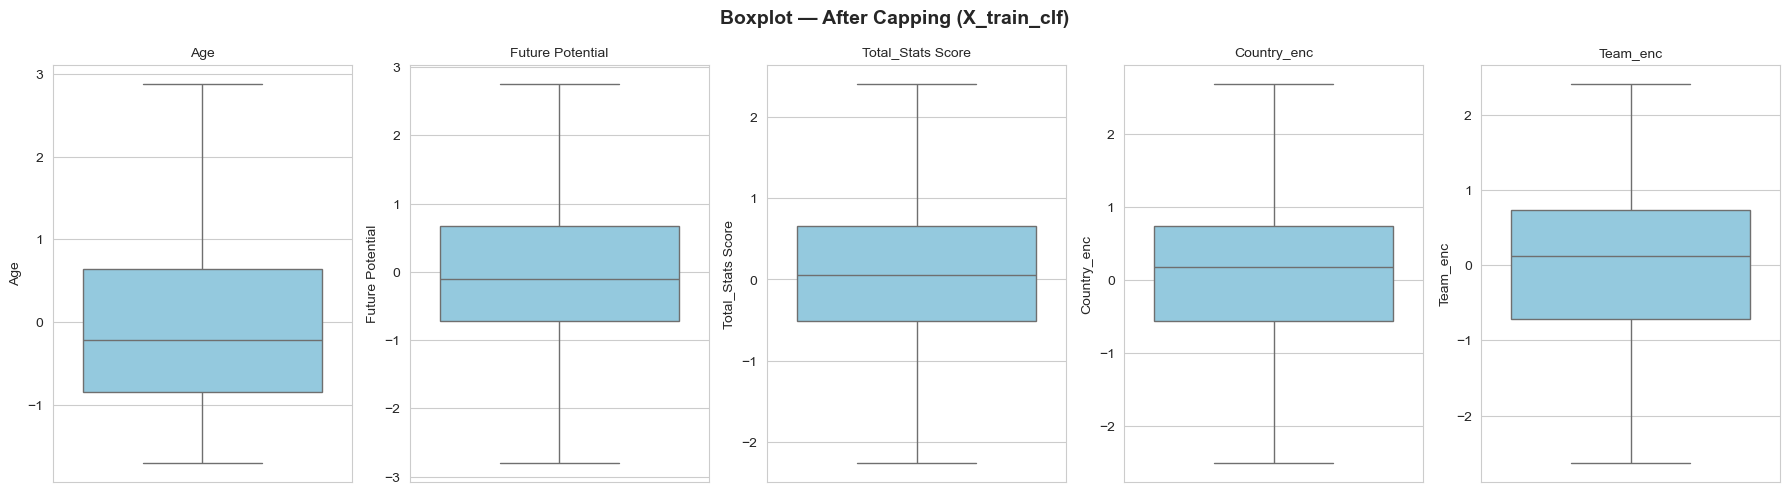

In [81]:
caps = {}

for col in num_cols_clf:
    Q1 = X_train_clf[col].quantile(0.25)
    Q3 = X_train_clf[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    caps[col] = (lower, upper)

    X_train_clf[col] = X_train_clf[col].clip(lower, upper)

for col in num_cols_clf:
    lower, upper = caps[col]
    X_test_clf[col] = X_test_clf[col].clip(lower, upper)

print("\nAfter Capping:")
print(X_train_clf[num_cols_clf].describe().round(2))

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplot — After Capping (X_train_clf)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_clf):
    sns.boxplot(y=X_train_clf[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [82]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,0.427468,67,-0.102151,0.547828,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.627229,0.067677
10392,-0.852089,55,-0.410505,-0.643544,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.261387,-0.158581
8124,1.920283,75,0.668734,1.816744,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.134039,-0.270865
13075,-1.278607,61,0.052026,-0.301641,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.042711,-0.176513
19445,1.067246,69,-0.256328,0.755789,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025438,-0.326069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.852089,59,-0.102151,0.516105,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.793126,-0.444612
11964,0.853986,67,-0.410505,0.082558,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.520911,-0.402302
5390,0.214208,63,-0.564682,0.121331,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.693890,-0.465204
860,0.427468,81,1.747973,1.792070,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.560311,0.372460


In [ ]:
X_train_clf

,Age,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,Position_LM,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,0.427468,-0.102151,0.547828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.795652,-0.278140
10392,-0.852089,-0.410505,-0.643544,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.379479,-0.390123
8124,1.920283,0.668734,1.816744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.658183,0.169793
13075,-1.278607,0.052026,-0.301641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.544554,0.029814
19445,1.067246,-0.256328,0.755789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.499827,-0.390123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.852089,-0.102151,0.516105,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.459926,0.480858
11964,0.853986,-0.410505,0.082558,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.941367,0.869689
5390,0.214208,-0.564682,0.121331,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.807894,1.196307
860,0.427468,1.747973,1.792070,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.992160,-1.509956
